# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 정상성이란 데이터의 일정한 공분산, 분산, 평균과 같이 데이터 본질의 변하지 않는 특성을 나타낸다. 이 정상성이 만족한다면 시계열 데이터의 패턴이 반복된다고 생각할 수 있다. 비정상성을 가진 데이터는 차분을 통해 비정상성을 제거해야한다. ARIMA모델은 비정상 데이터를 차분하여 추세를 제거하는 모델이다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. ACF가 매우 천천히 감소한다는 특성을 볼 때, 추세를 가진 비정상 시계열로 생각된다. 적절한 모형은 ARIMA(0,1,q)이다. 1차 차분 후 ACF가 절단되었으니, AR(p) 성분은 없으니 p=0이고, 차분 횟수인 d=1, 과거의 예측 오차($q$)를 활용해 변동을 설명할 수 있다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [1]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/content/Weather Station Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [2]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/content/Summary of Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_495/1466873862.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/content/Summary of Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [3]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_495/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_495/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


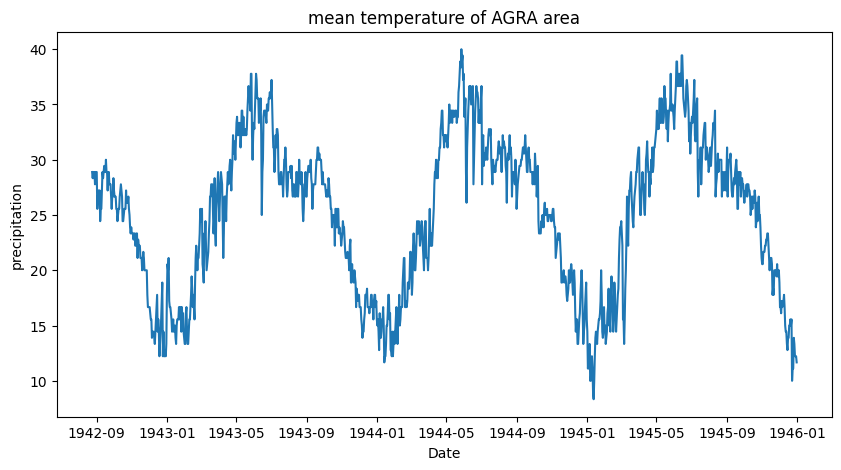

In [4]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [5]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

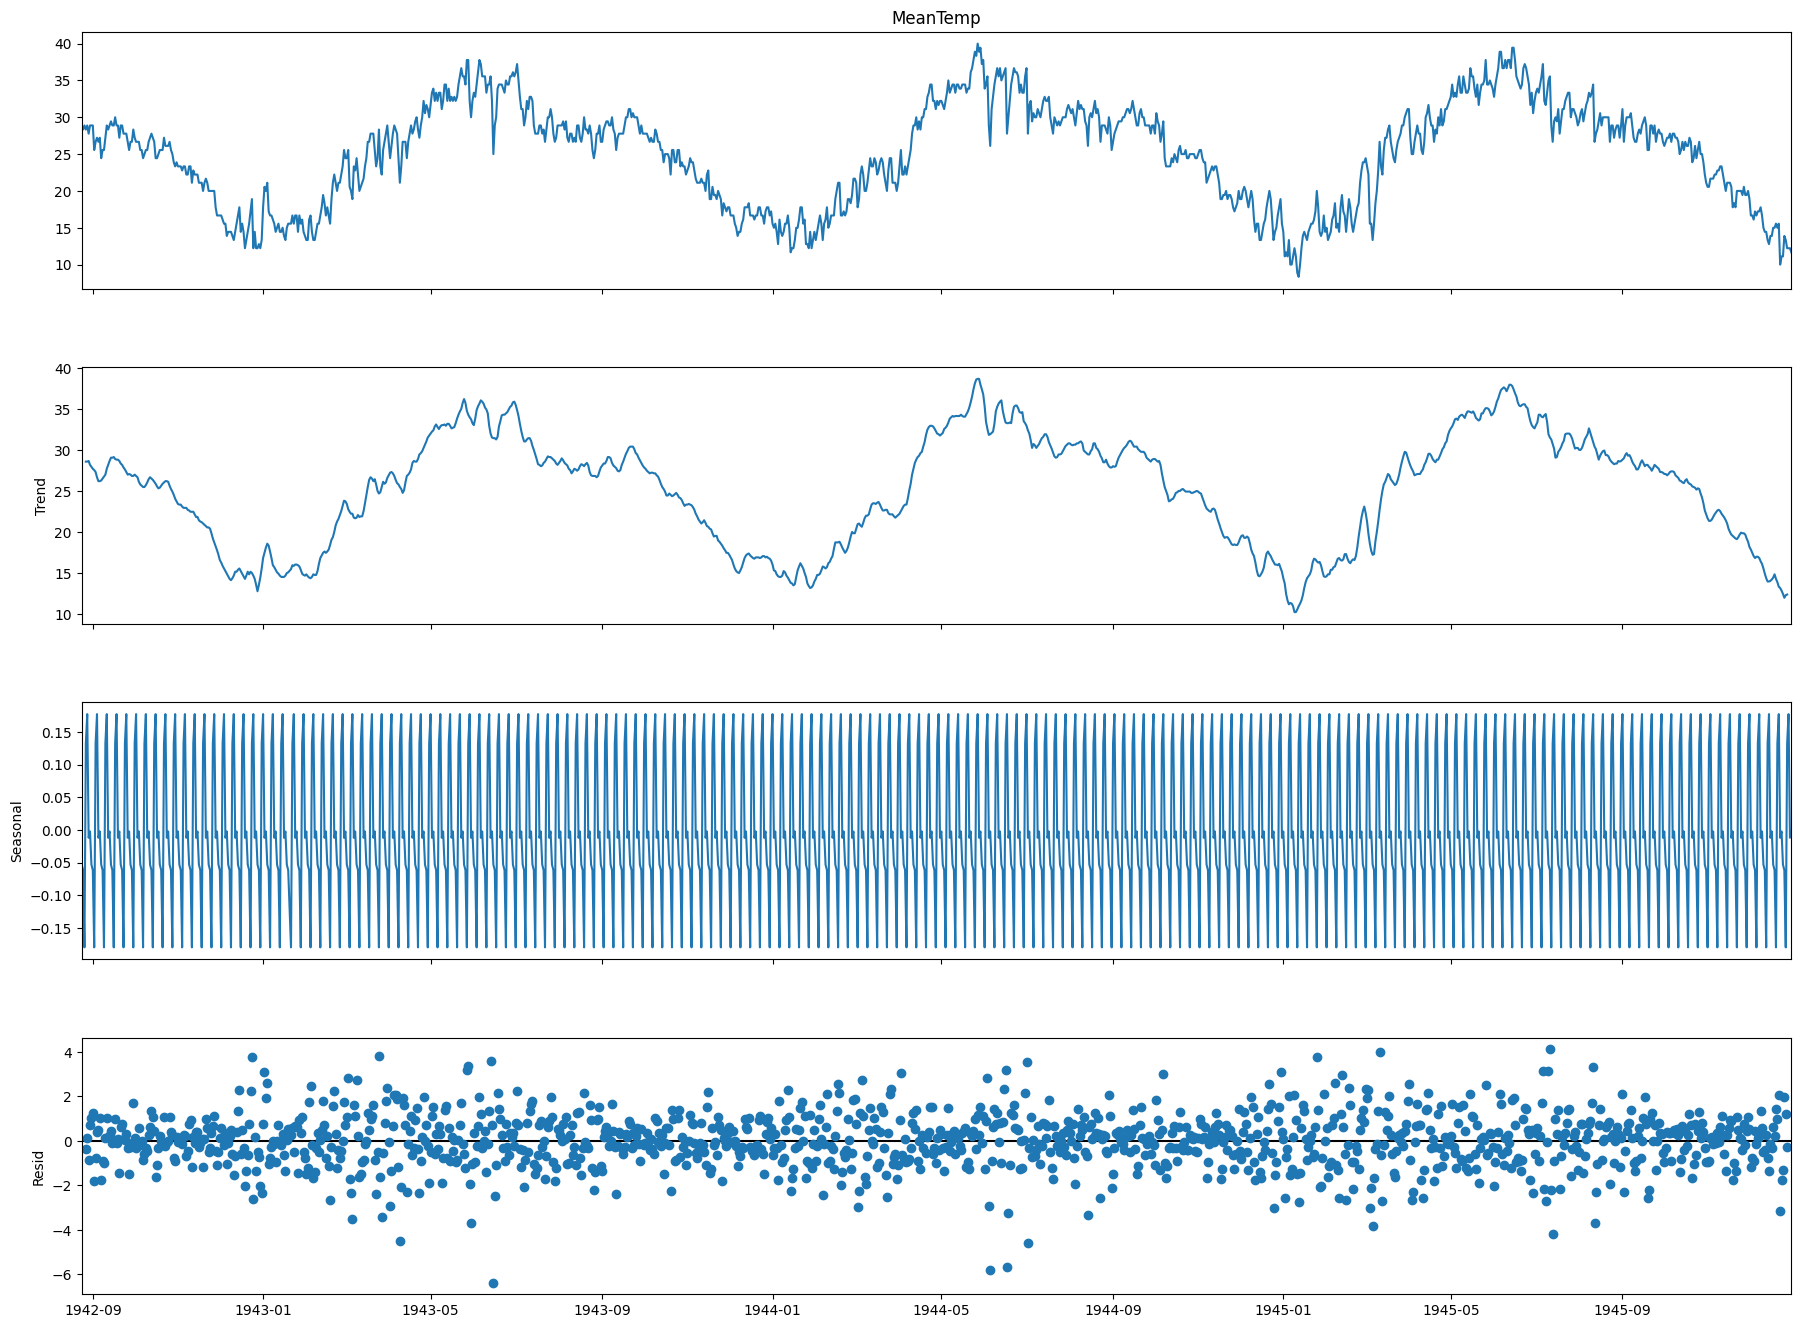

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

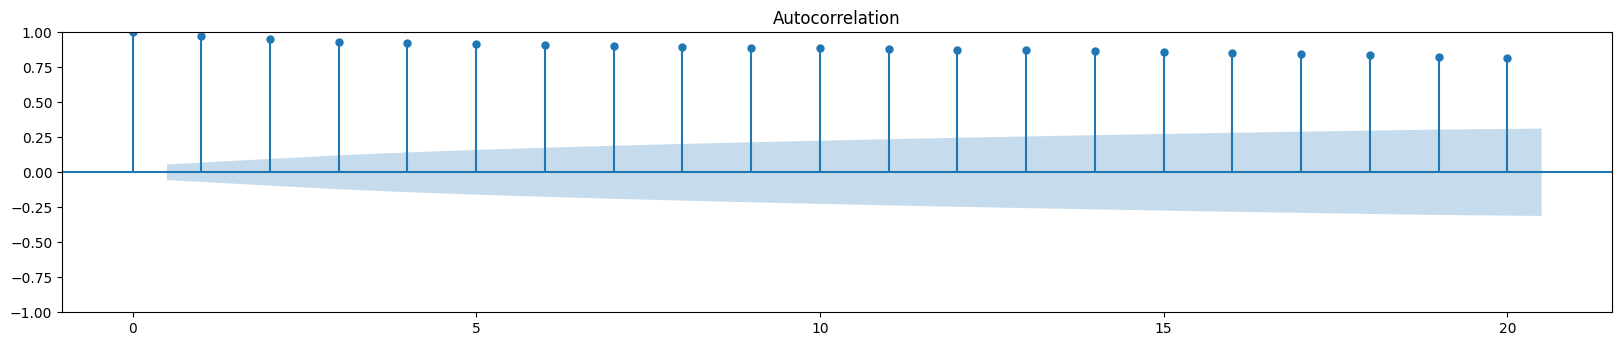

In [7]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [8]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.



A1.

ADF 검정의 귀무가설: 시계열 데이터가 비정상적이다.

ADF 검정의 대립가설: 시계열 데이터가 정상성을 띈다.

p-value가 약 0.260으로 일반적인 유의수준인 0.05보다 훨씬 큽니다. 또한, 검정 통계량(-2.062)이 임계값(5%: -2.864)보다 큽니다.

따라서 귀무가설을 기각할 수 없으므로, 이 데이터는 추세나 계절성을 띠는 비정상 시계열로 판단해야 한다.

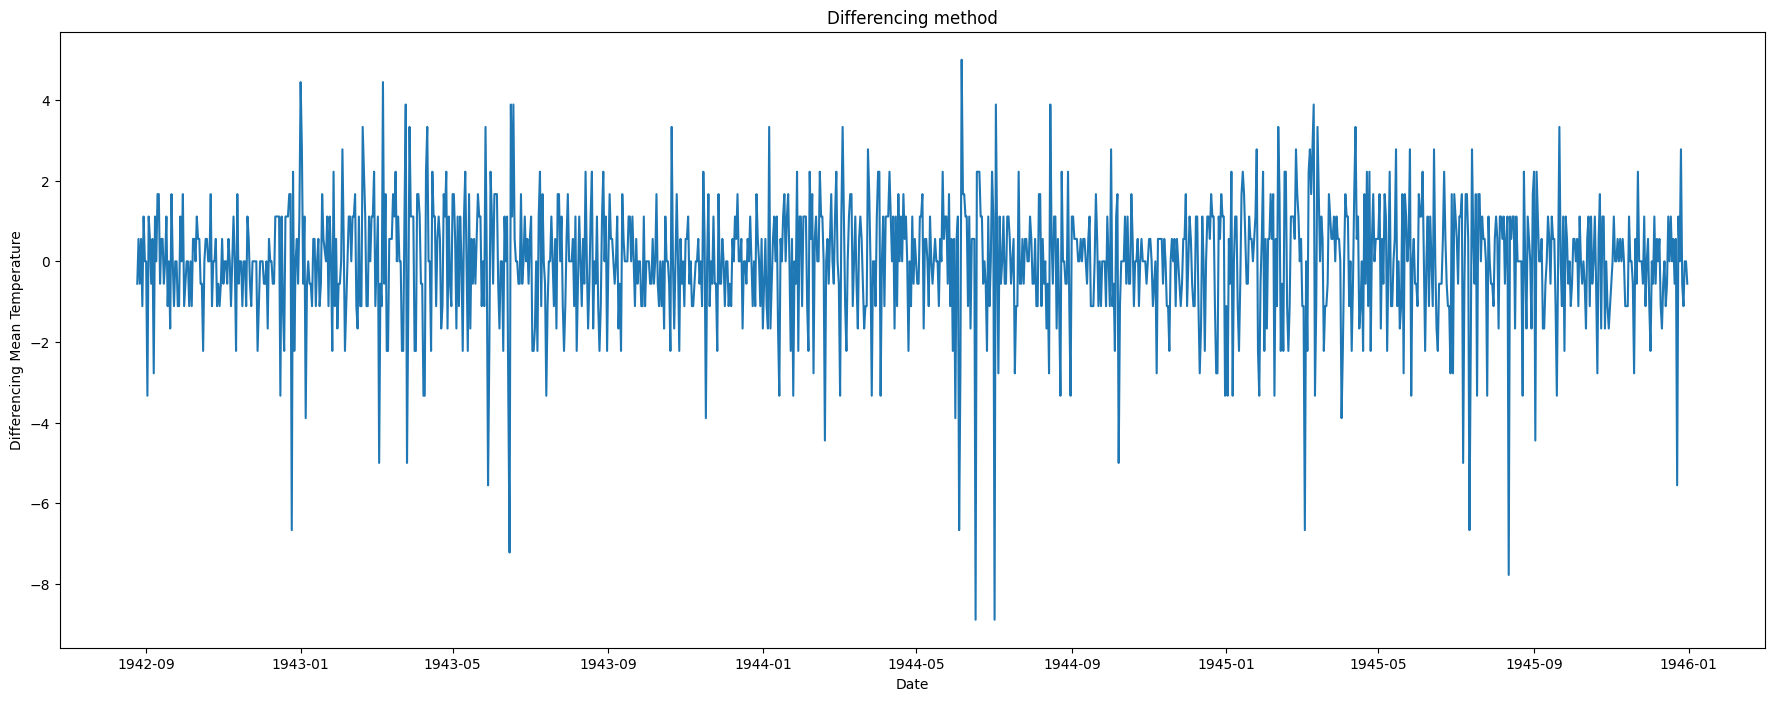

In [9]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [10]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. p-value값이 0으로 급감하였고, ADF Statistic값이 -2.062에서 -6.295로 낮아져, 가장 엄격한 기준인 1% 임계값보다도 작아졌다. 귀무가설이 기각되고, 대립가설을 채택하게 되었다.

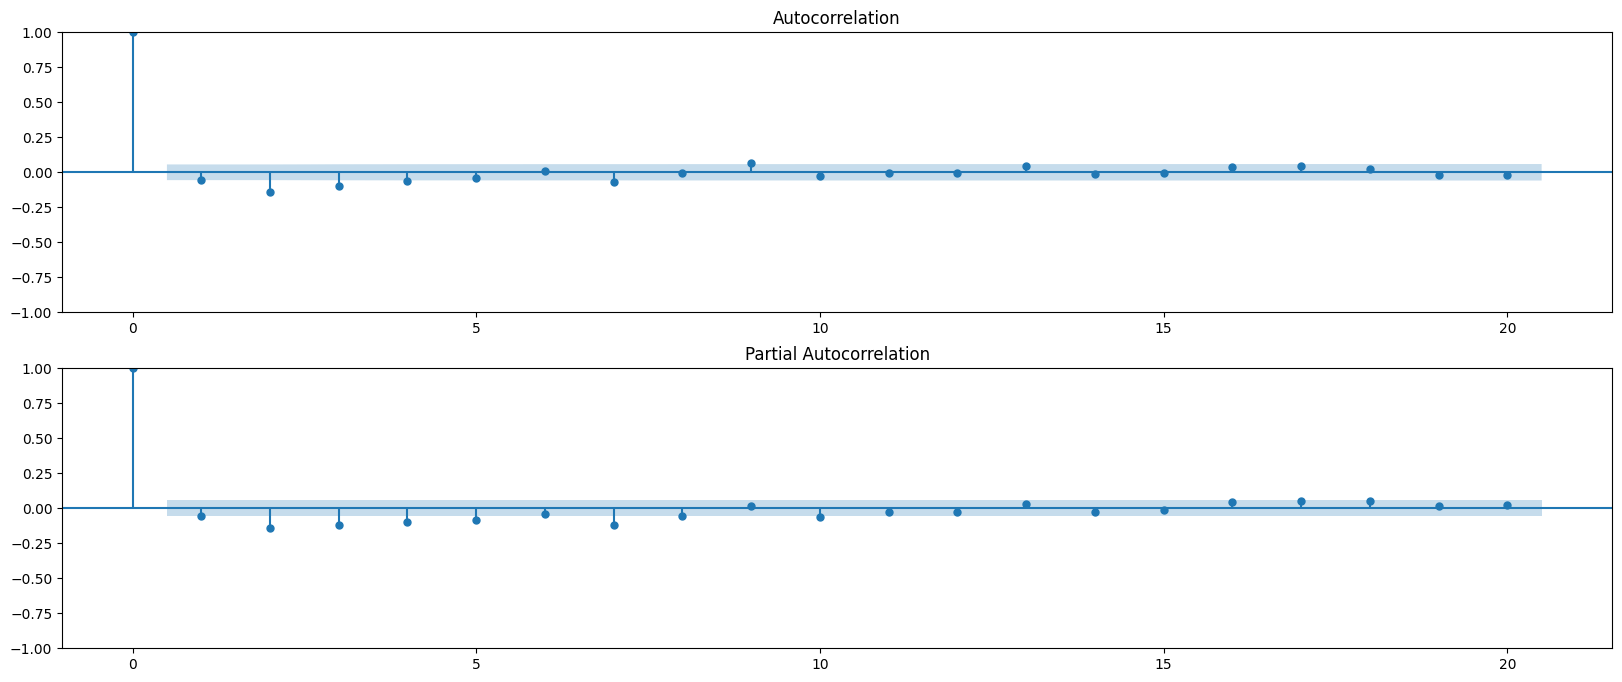

In [11]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.

위쪽 그래프인 ACF를 보면 Lag 2에서 신뢰구간을 아래로 뚜렷하게 벗어나는 유의미한 값을 가진 후, 시차 3부터는 사실상 절단되는 형태를 보입니다. 이는 이동평균(MA) 차수 q=2를 시사합니다.

PACF (아래쪽 그래프): 시차 2, 3, 4 등 여러 시차에서 신뢰구간 경계에 걸치며 진동형으로 점진적 감소(Tail-off)하는 패턴을 보입니다. 이는 자기회귀(AR) 특성이 낮음을 의미하므로 $p=0$을 시사합니다.결론: 이전 단계에서 확인한 1차 차분($d=1$)과 결합하여, ARIMA(0, 1, 2) 모형이 가장 적절한 기본 후보로 판단됩니다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


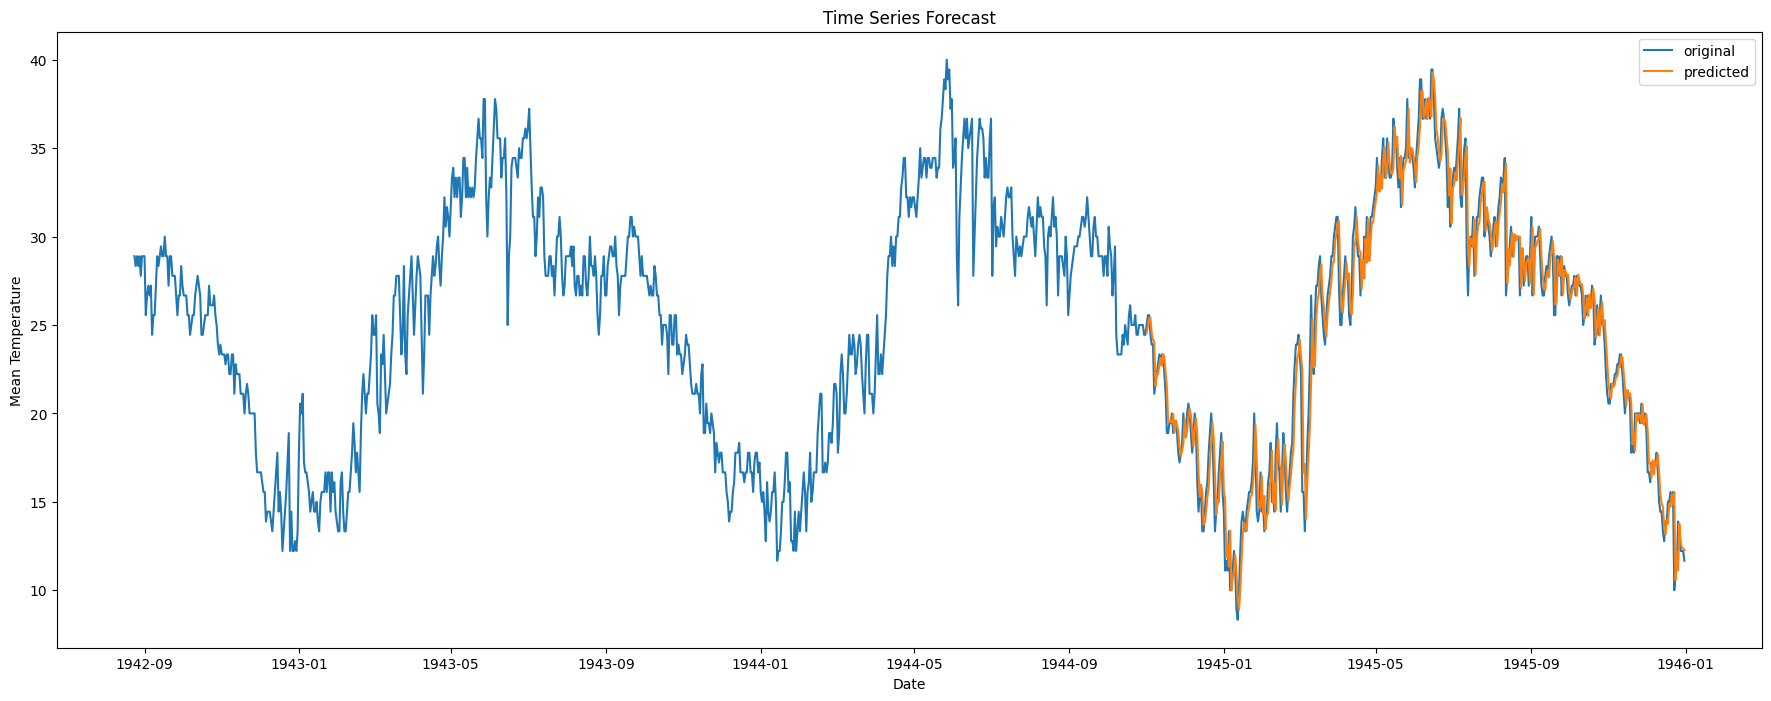

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 2

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_495/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


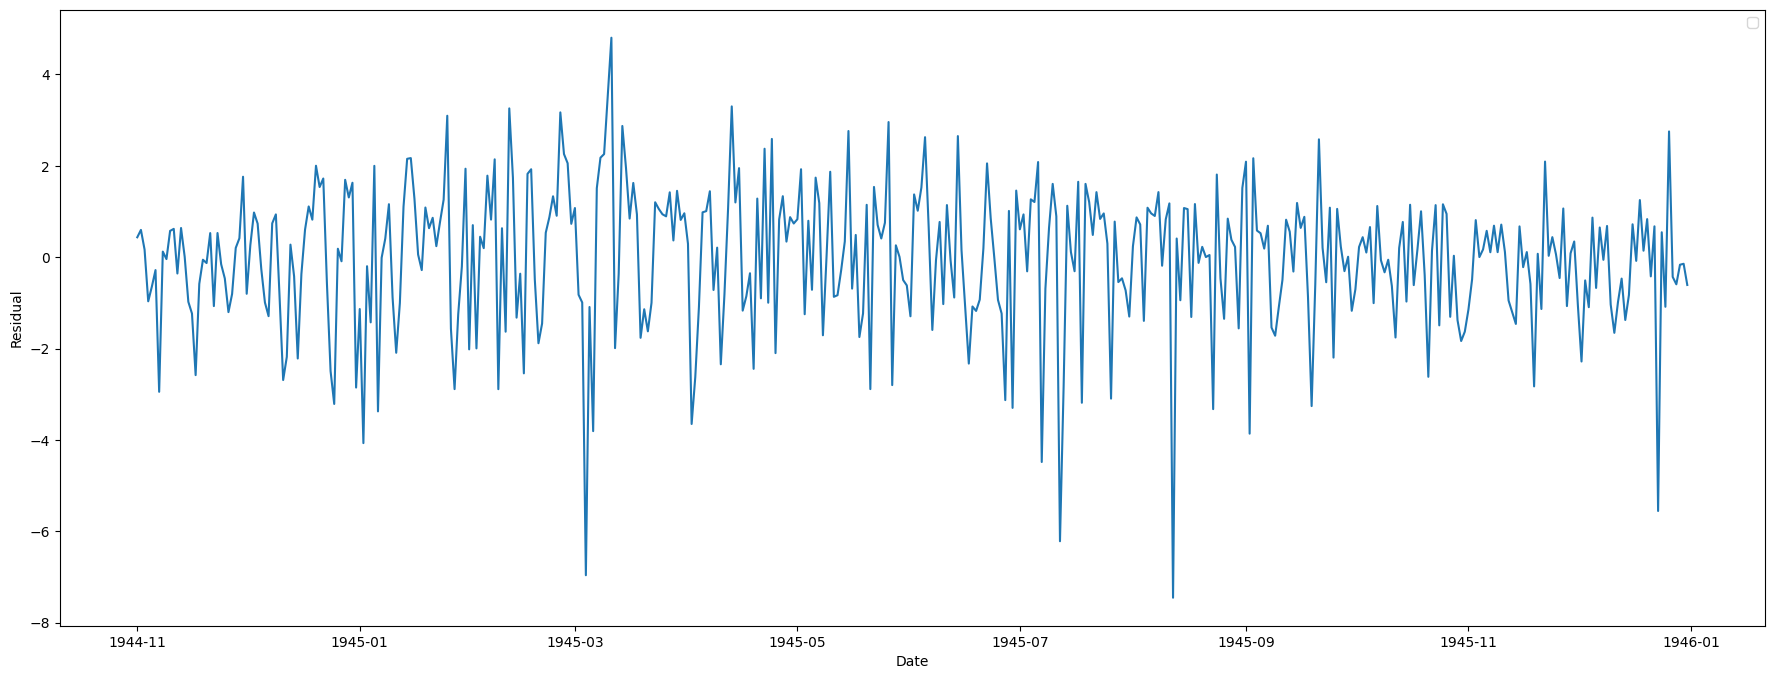

In [14]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

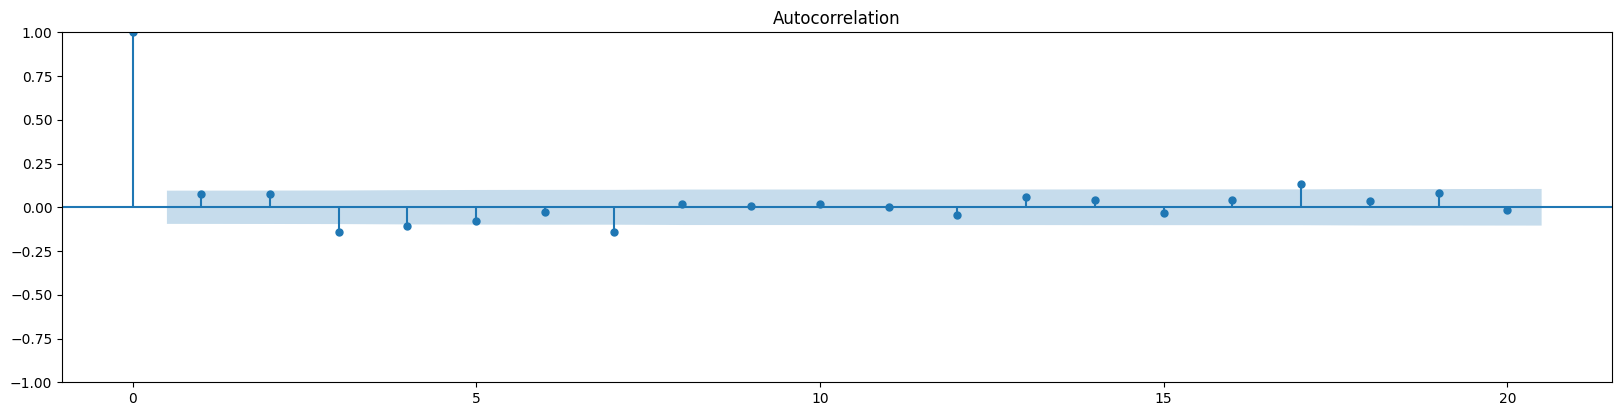

In [15]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [16]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.592822
p-value: 0.000133
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [17]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [18]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.617,0.978,1.555,5.475


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.

R2(결정계수)값이 95.617%로 거의 완벽하게 모델이 실제 데이터의 변동성을 설명하고 있다. Corr(상관계수)값은 0.978로 실제값과 예측값이 매우 가까운 강한 양의 선형 관계를 가진다. RMSE값은 1.555이므로 예측된 기온이 실제 기온과 평균적으로 약 1.555도 정도의 차이가 난다. MAPE는 5.475%로, 예측값이 실제값 대비 평균적으로 약 5.47%의 오차 비율을 보인다. 10% 미만이므로 매우 정확한 예측으로 볼 수 있다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.

1. 최적의 하이퍼파라미터 값 및 판단 근거

최적 파라미터: kernel_size=31, learning rate=0.0005, epochs=120,  weight_decay=1e-4

판단 근거: 기존 설정은 이동평균이 일직선으로 뭉개지고 가중치가 요동쳐 R2가 40%대에 머물렀습니다. 이를 해결하기 위해 kernel_size를 한 달 주기(31)로 변경하여 기온의 단기 추세와 계절성을 명확히 분리했습니다. 또한, 과적합을 막기 위해 학습률을 0.0005로 낮추고 weight_decay를 추가했으며, 낮아진 학습 속도를 보완하기 위해 epochs를 120으로 늘렸습니다. 그 결과 예측 그래프의 비정상적인 진동이 사라지고 실제 기온 곡선을 안정적으로 추적하게 되었으며, 수치상으로도 R2 88.151%, RMSE 2.377이라는 매우 낮은 오차율과 높은 설명력을 객관적으로 달성했습니다.

2. 해당 기온 데이터셋에는 DLinear 모델이 더 적합합니다. 기온 데이터는 1년 주기의 뚜렷한 계절성을 가집니다. ARIMA 모형은 과거 1~2일의 단기 오차에만 의존하므로, 장기 예측 시 1년 주기의 굴곡을 그리지 못하고 결국 평균치에 수렴하는 한계가 있습니다. 반면, DLinear 모델은 구조적으로 시계열 데이터에서 추세와 계절성을 강제로 분리하여 독립적으로 학습합니다. 따라서 장기 예측 시에도 기온 본연의 주기적 진폭 패턴을 소실 없이 정확하게 보존할 수 있습니다.

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [21]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [93]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [94]:
model = DLinear(seq_len, pred_len, kernel_size=31).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 120

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.004339
Epoch 20, Loss: 0.003687
Epoch 30, Loss: 0.003376
Epoch 40, Loss: 0.003451
Epoch 50, Loss: 0.003185
Epoch 60, Loss: 0.003055
Epoch 70, Loss: 0.003071
Epoch 80, Loss: 0.003142
Epoch 90, Loss: 0.003223
Epoch 100, Loss: 0.003301
Epoch 110, Loss: 0.003186
Epoch 120, Loss: 0.003180


In [95]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

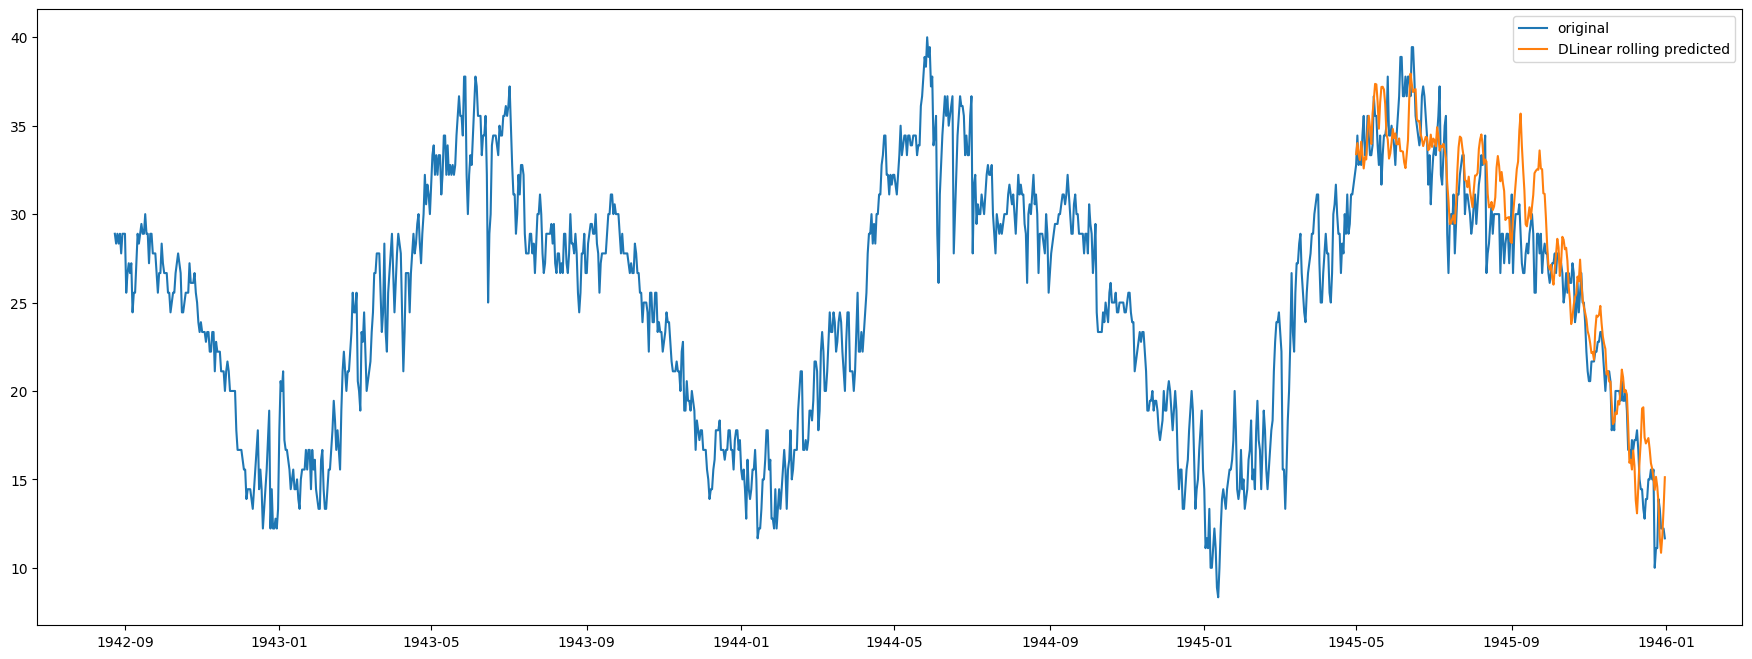

In [96]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [97]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,88.151,0.948,2.377,7.356


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [98]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


### 1. 분석 대상 및 요인 선정
* **선정 도시:** WALLER/BWI (데이터 건수 1600건 이상으로 학습 안정성 확보)
* **분석 요인:** MaxTemp (최고기온 - 뚜렷한 1년 주기 계절성을 띠는지 확인하기 위함)

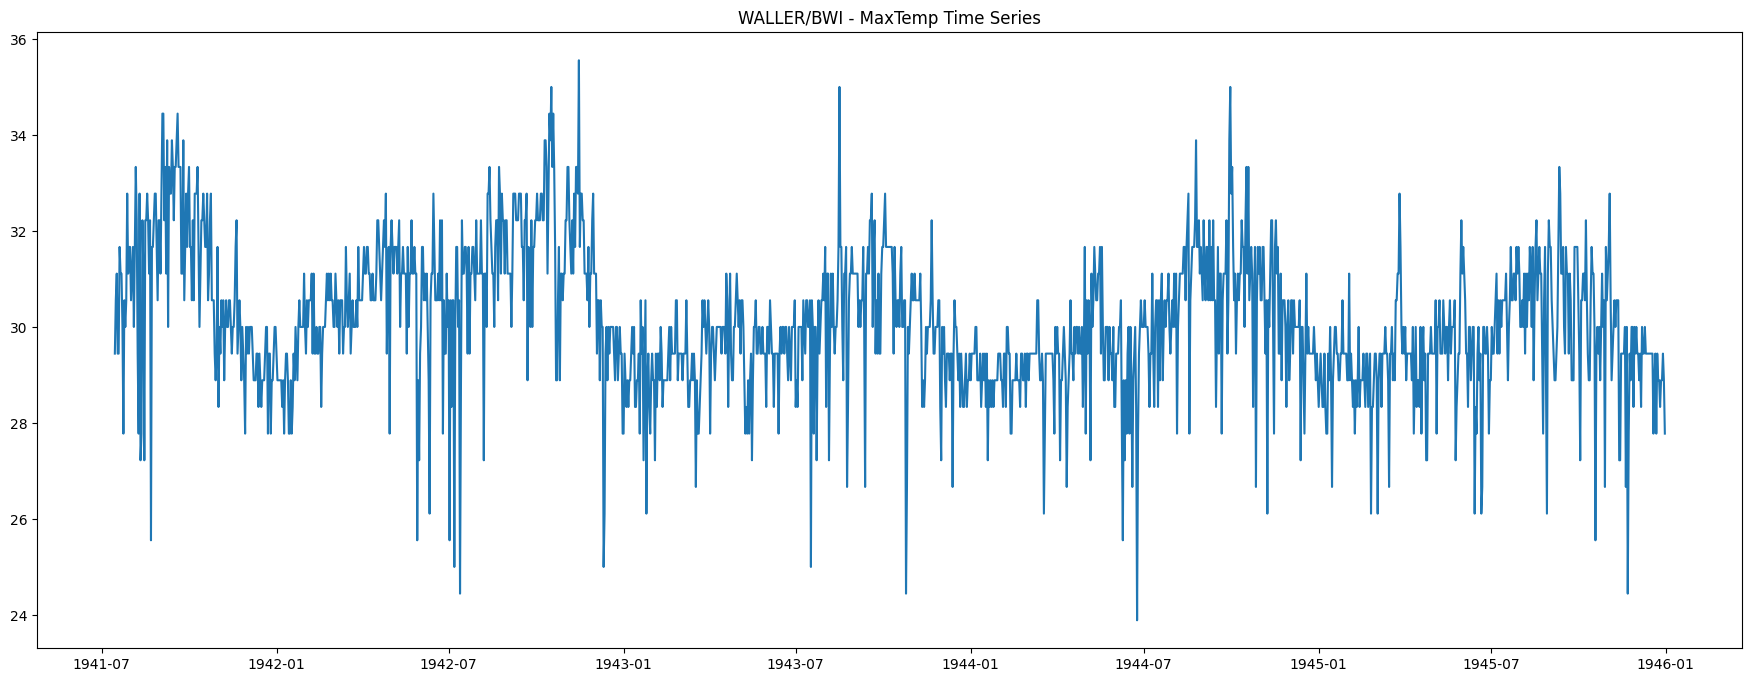

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 추출 및 정렬
weather_bin = merged[merged['NAME'] == 'WALLER/BWI'].copy()
weather_bin['Date'] = pd.to_datetime(weather_bin['Date'])
weather_bin = weather_bin.sort_values('Date')

# ts 변수 생성 (결측치 제거)
ts = weather_bin.set_index('Date')['MaxTemp'].dropna()

# EDA 시각화
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values)
plt.title("WALLER/BWI - MaxTemp Time Series")
plt.show()

### 2. DLinear 모델 학습 준비
* 최고기온(MaxTemp) 데이터의 추세와 계절성을 분리하여 학습하기 위해 DLinear 모델을 구축합니다.
* 이전 분석에서 도출된 최적 하이퍼파라미터(kernel_size=31, lr=0.0005, epochs=120)를 적용합니다.

In [101]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = ts.values.reshape(-1, 1) # 스케일러 오류 방지를 위해 2D 배열로 조정

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len, kernel_size=31): # 커널 31 적용
        super().__init__()
        self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend = nn.Linear(seq_len, pred_len)

    def series_decomp(self, x):
        x = x.permute(0, 2, 1)
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

    def forward(self, x):
        seasonal, trend = self.series_decomp(x)
        seasonal = seasonal.squeeze(1)
        trend = trend.squeeze(1)
        return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [102]:
model = DLinear(seq_len, pred_len, kernel_size=31).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 120

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.009618
Epoch 20, Loss: 0.008591
Epoch 30, Loss: 0.007952
Epoch 40, Loss: 0.008001
Epoch 50, Loss: 0.008031
Epoch 60, Loss: 0.007889
Epoch 70, Loss: 0.007800
Epoch 80, Loss: 0.007783
Epoch 90, Loss: 0.007921
Epoch 100, Loss: 0.007805
Epoch 110, Loss: 0.007822
Epoch 120, Loss: 0.007881


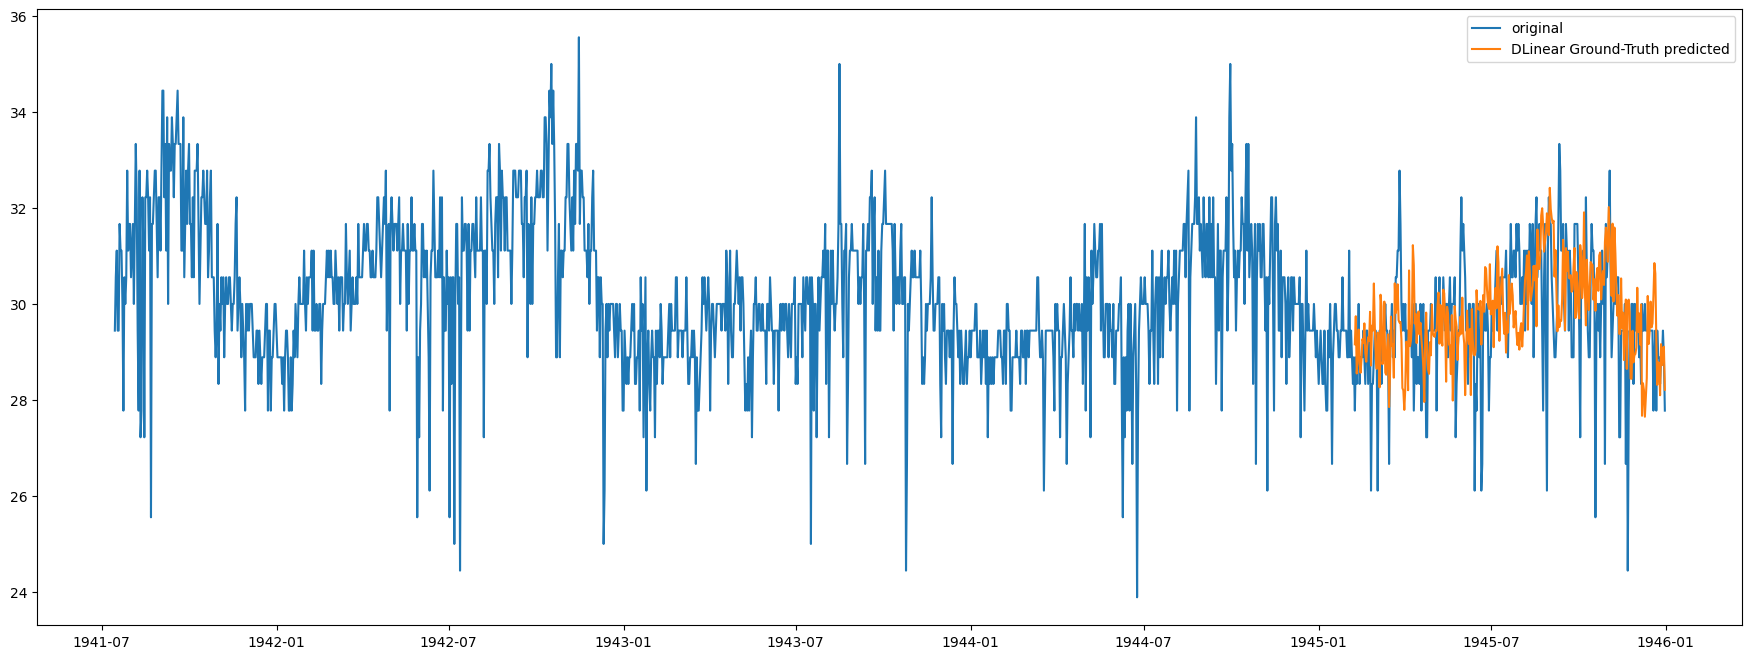

,R2,Corr,RMSE,MAPE
0,-14.526,0.263,1.365,3.47


In [104]:
model.eval()
predictions = []

# 전체 데이터를 합쳐서 실제 데이터 슬라이딩용으로 준비
all_scaled_data = np.concatenate((train_scaled, test_scaled))
total_test_len = len(test_scaled)

step = 0
# 가짜 예측값을 넣지 않고, 실제 정답 데이터를 30일씩 밀어가며 예측 (누적 오차 원천 차단)
while len(predictions) < total_test_len:
    start_idx = train_size - seq_len + step
    current_window = all_scaled_data[start_idx : start_idx + seq_len]

    x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).cpu().numpy().flatten()

    remaining = total_test_len - len(predictions)
    pred = pred[:remaining]
    predictions.extend(pred)

    step += pred_len # 30일씩 슬라이딩

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

# 시각화
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")
test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(), label="DLinear Ground-Truth predicted")
plt.legend()
plt.show()

# Scoring 실행
test_start_idx = train_size
y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

scoring(y_true, y_pred)

분석 대상 선정 및 과정 요약

이번 분석에서는 데이터가 충분한 월러 비행장 지역을 선정하였으며, 분석 요인으로는 해당 지역의 최고기온을 선택했습니다. 분석 과정은 기존 실습과 동일하게 진행되었습니다. 먼저 대상 데이터를 추출하여 날짜 순으로 정렬하고 결측치를 처리하는 전처리 단계를 거쳤습니다. 이후 최고기온 데이터의 특성을 파악하기 위한 시계열 시각화를 수행하였고, 이전 단계에서 도출된 최적의 하이퍼파라미터인 커널 사이즈 31, 학습률 0.0005, 에포크 120을 적용하여 딥러닝 모델 학습을 완료했습니다. 마지막으로 모델의 예측 결과가 실제 데이터와 얼마나 일치하는지 확인하기 위해 오차 평가지표를 산출하였습니다.

실습 1과의 차이점:

실습 1에서 진행한 아그라 지역의 강수량 데이터와 이번에 분석한 월러 비행장의 최고기온 데이터를 비교했을 때, 가장 먼저 데이터의 연속성 측면에서 뚜렷한 차이가 나타났습니다. 아그라의 강수량은 비가 오지 않는 날이 많아, 수치가 0에 머무는 구간이 매우 길고 간헐적으로 값이 튀는 불규칙한 양상을 보였습니다. 반면 이번 기온 데이터는 중단 없이 수치가 이어지며, 30도에서 32도 사이의 매우 좁은 범위 내에서 데이터가 밀집되어 나타나는 특징을 보였습니다.

지표 해석을 통해 도출된 새로운 인사이트

분석 결과, 실제 기온과 예측값의 평균 오차인 RMSE는 1.36도, 오차율인 MAPE는 3.47%로 매우 우수하게 나타났습니다. 하지만 결정계수인 R2 점수는 음수인 -14.5%를 기록하는 독특한 현상이 발생했습니다. 이는 분석 대상인 월러 비행장 지역이 1년 내내 기온 변화가 거의 없는 열대 기후이기 때문입니다. 데이터 자체의 분산이 0에 가깝다 보니, 모델이 평균 기온인 31도를 매우 정확하게 예측하더라도 통계 수식상 설명력을 인정받지 못하는 지표의 역설이 발생한 것입니다.

결론적으로 모든 시계열 분석에서 특정 지표가 항상 모델의 성능을 대변하지는 않는다는 인사이트를 얻었습니다. 강수량처럼 0이 많은 데이터는 오차율 왜곡을 주의해야 하며, 이번 기온 데이터처럼 변동 폭이 극도로 적은 지역은 결정계수보다 절대적인 온도 오차 지표를 우선 신뢰해야 합니다. 이는 데이터에 대한 이해가 우선적으로 수반되어야 한다는 사실을 보여줍니다.